# Problem 1

In [1]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 

# data (as pandas dataframes) 
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 

# metadata 
print(banknote_authentication.metadata) 

# variable information 
print(banknote_authentication.variables)

print(X.head())
print(y.head())

{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=598, 
    stratify=y
)

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import zero_one_loss

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

linreg_y_pred = linreg_model.predict(X_test)
linreg_y_pred_bin = np.where(linreg_y_pred >= 0.5, 1, 0)
linreg_misclass_rate = zero_one_loss(y_test, linreg_y_pred_bin)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_y_preds = []
knn_misclass_rate = []
for k in range(1, 21):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train.squeeze())
    
    y_preds = knn_model.predict(X_test)
    knn_y_preds.append(y_preds)

    misclass_rate = zero_one_loss(y_test, y_preds)
    knn_misclass_rate.append(misclass_rate)

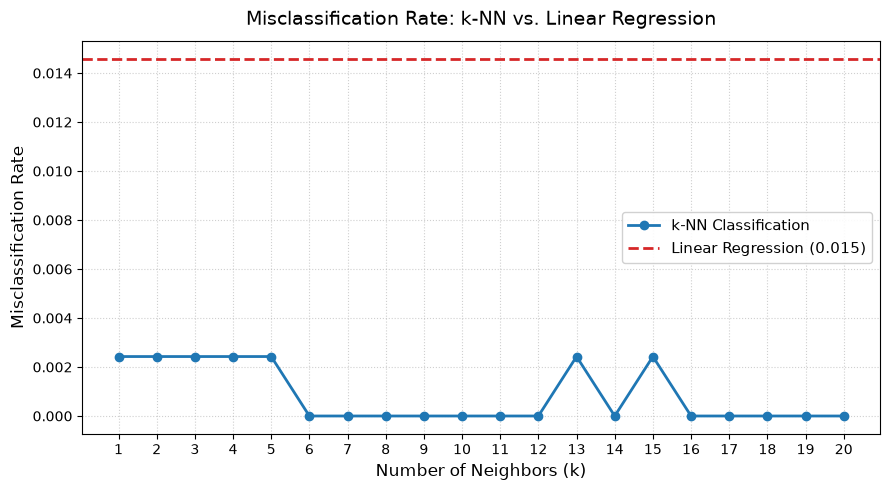

In [5]:
import matplotlib.pyplot as plt

k_values = list(range(1, 21))

plt.figure(figsize=(9, 5), dpi=100)

# Plot KNN Misclassification Rate
plt.plot(
    k_values, 
    knn_misclass_rate, 
    marker='o', 
    linewidth=2, 
    color='#1f77b4', 
    label='k-NN Classification'
)

# Plot Linear Regression Misclassification Rate (Horizontal Baseline)
plt.axhline(
    y=linreg_misclass_rate, 
    color='#d62728', 
    linestyle='--', 
    linewidth=2, 
    label=f'Linear Regression ({linreg_misclass_rate:.3f})'
)

# Formatting and Labels
plt.title('Misclassification Rate: k-NN vs. Linear Regression', fontsize=14, pad=12)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Misclassification Rate', fontsize=12)
plt.xticks(k_values)  # Show integer ticks for every k

# Grid, Legend, and Layout Cleanups
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()

plt.show()

In [6]:
print(X_train.shape[0])
print(X_train.shape[0] / 6)

960
160.0


### Does the plot match (approximately) your intuition of the bias–variance trade-off in terms of having a U-shaped error?

No, my results do not follow a U-shaped error. My plot is an almost flat near zero error since the dataset features are extracted from image wavelet transforms, the two classes are almost completely linearly and non-linearly separable. When classes are distinctly partitioned in feature space, k-NN can expand k up to 20 without capturing enough other class points to underfit.

### What is the optimal k value based on this result?

There a handful of ks with zero error so going with the first one k=6 is optimal.

### For the optimal k, what are the corresponding degrees-of-freedom and its error?

$ N_{train} / k_{optimal} = 960/6 = 120 $

# Problem 2

In [7]:
rng = np.random.default_rng(seed=598)

n_samples = 1000

X1 = rng.standard_normal(n_samples)
X2 = rng.standard_normal(n_samples)
X3 = rng.standard_normal(n_samples)

epsilon = rng.standard_normal(n_samples)

Y = X1 + (2 * X2) - X3 + (0.5 * X1 * X2) + epsilon

X = np.column_stack((X1, X2, X3))
X_train, X_test = X[:500], X[500:]
y_train, y_test = Y[:500], Y[500:]

In [8]:
def euclidean(X, x_target, w):
    return np.sum(w * (X - x_target)**2, axis=1)

def approx_y(x, beta):
    return beta[0] + np.sum(x * beta[1:])

def mykNN(xtrain, ytrain, xtest, k):
    y_hat = np.zeros(len(xtest))

    for i in range(len(xtest)):
        distances = euclidean(xtrain, xtest[i], 1)
        smallest_k_indices = np.argpartition(distances, k)[:k]
        neighbor_indices = smallest_k_indices[np.argsort(distances[smallest_k_indices])]

        x_neighbors = xtrain[neighbor_indices]
        y_neighbors = ytrain[neighbor_indices]

        xdesign = np.column_stack((np.ones(k), x_neighbors))
        beta_hat, residuals, rank, s = np.linalg.lstsq(xdesign, y_neighbors, rcond=None)

        y_hat_local = approx_y(xtest[i], beta_hat)
        y_hat[i] = y_hat_local

    return y_hat

def mean_squared_error(y, y_hat):
    n = y.shape[0]
    return 1/n * np.sum((y - y_hat)**2)

In [9]:
from sklearn.neighbors import KNeighborsRegressor

k_values = [1, 5, 10, 20]
knn_y_preds = []
knn_mse = []
my_knn_mse = []
for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=2)
    knn_model.fit(X_train, y_train)

    my_y_preds = mykNN(X_train, y_train, X_test, k)
    my_mse = mean_squared_error(y_test, my_y_preds)
    my_knn_mse.append(my_mse)

    y_preds = knn_model.predict(X_test)
    mse = mean_squared_error(y_test, y_preds)
    knn_mse.append(mse)

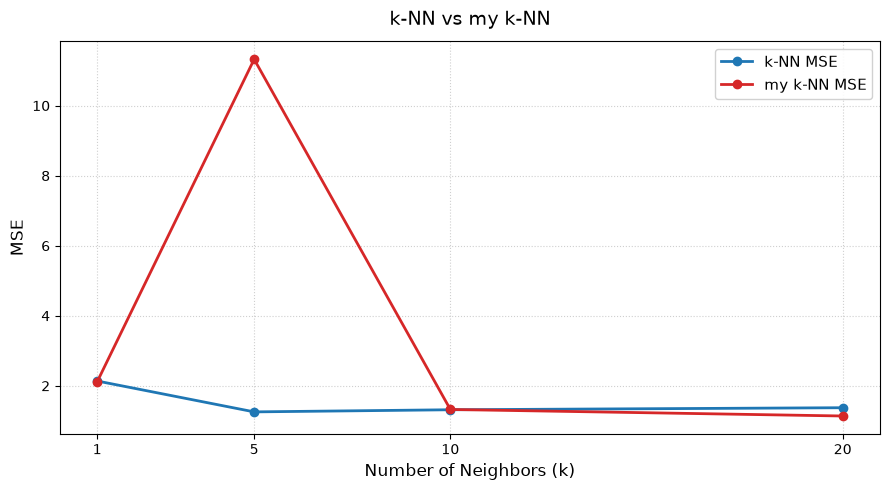

In [10]:
plt.figure(figsize=(9, 5), dpi=100)

# Plot KNN MSE
plt.plot(
    k_values, 
    knn_mse, 
    marker='o', 
    linewidth=2, 
    color='#1f77b4', 
    label='k-NN MSE'
)

# Plot my KNN MSE
plt.plot(
    k_values,
    my_knn_mse,
    marker='o',
    color='#d62728',
    linewidth=2,
    label=f'my k-NN MSE'
)

# Formatting and Labels
plt.title('k-NN vs my k-NN', fontsize=14, pad=12)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.xticks(k_values)  # Show integer ticks for every k

# Grid, Legend, and Layout Cleanups
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()

plt.show()